# Task 5 – Uncertainty Evaluation
The model is run multiple times with dropout to measure uncertainty.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
# Paths to data
train_images_folder = "Data/Training/Training_Images"
train_csv = "Data/Training/Training_LabelsDemographic.csv"

test_images_folder = "Data/Testing/Testing_Images"
test_csv = "Data/Testing/Testing_LabelDemographic.csv"

# Load labels
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

train_df.head()

,image,myopic_maculopathy_grade,age,sex,height,weight,data_center
0,mmac_task_1_train_0001.png,0,51,male,183.5,78.9,1
1,mmac_task_1_train_0002.png,0,51,male,183.5,78.9,1
2,mmac_task_1_train_0003.png,0,50,male,184.5,81.7,1
3,mmac_task_1_train_0004.png,0,50,male,184.5,81.7,1
4,mmac_task_1_train_0005.png,0,49,male,184.5,82.2,1


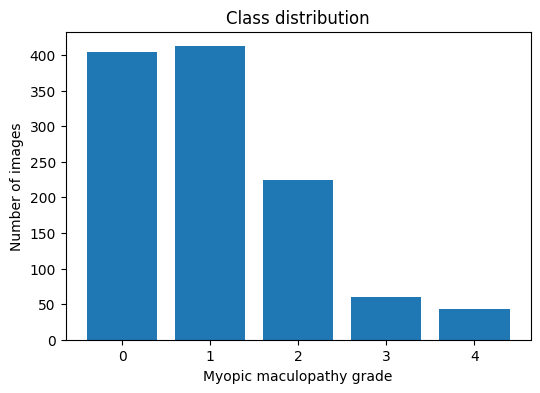

In [3]:
# Class distribution of dataset to identify imbalance
class_counts = train_df["myopic_maculopathy_grade"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Myopic maculopathy grade")
plt.ylabel("Number of images")
plt.title("Class distribution")
plt.xticks(class_counts.index)
plt.show()

## Data transformation

In [4]:
# Image preprocessing: Images are converted to grayscale resized and normalised
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])])

In [5]:
# Custom dataset to load images and corresponding labels
class MMACDataset(Dataset):
    def __init__(self, df, images_folder, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_folder = images_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name = self.df.iloc[idx]["image"]
        label = int(self.df.iloc[idx]["myopic_maculopathy_grade"])

        image_path = os.path.join(self.images_folder, image_name)
        image = Image.open(image_path).convert("L")

        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(label, dtype=torch.long),
            "image_name": image_name }

In [6]:
# dataset and dataloader
train_dataset = MMACDataset(train_df, train_images_folder, transform=transform)
test_dataset = MMACDataset(test_df, test_images_folder, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

## Classification model
CNN model to classify myopic maculopathy grade. Dropout is included so the model can be run multiple times to measure uncertainty.

In [7]:
# simple CNN model
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5, dropout_p=0.3):
        super().__init__()

        # Convolutional feature extraction
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2) )

        # Classification layers with dropout
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(64, num_classes) )

    def forward(self, x):
        # Forward pass
        x = self.features(x)
        x = self.classifier(x)
        return x

## Training setup
Train using cross-entropy loss and the Adam optimiser.

In [8]:
# Set device, loss function and optimiser
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=5, dropout_p=0.3)
model = model.to(device)

# Loss and optimiser
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Using device:", device)

Using device: cpu


In [9]:
# Train the model for one epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(loader):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [10]:
# Train model for multiple epochs and store loss and accuracy
num_epochs = 12

train_losses = []
train_accuracies = []

for epoch in tqdm(range(num_epochs), desc="Training"):
    train_loss, train_acc = train_one_epoch( model, train_loader, criterion, optimizer, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")

Training:   8%|▊         | 1/12 [00:29<05:24, 29.53s/it]

Epoch 1/12 - Loss: 1.4025, Accuracy: 0.3316


Training:  17%|█▋        | 2/12 [01:00<05:01, 30.19s/it]

Epoch 2/12 - Loss: 1.3200, Accuracy: 0.3517


Training:  25%|██▌       | 3/12 [01:29<04:28, 29.82s/it]

...

Epoch 10/12 - Loss: 1.1876, Accuracy: 0.4488


Training:  92%|█████████▏| 11/12 [05:20<00:29, 29.30s/it]

Epoch 11/12 - Loss: 1.1796, Accuracy: 0.4602


Training: 100%|██████████| 12/12 [05:53<00:00, 29.42s/it]

Epoch 12/12 - Loss: 1.1833, Accuracy: 0.4479


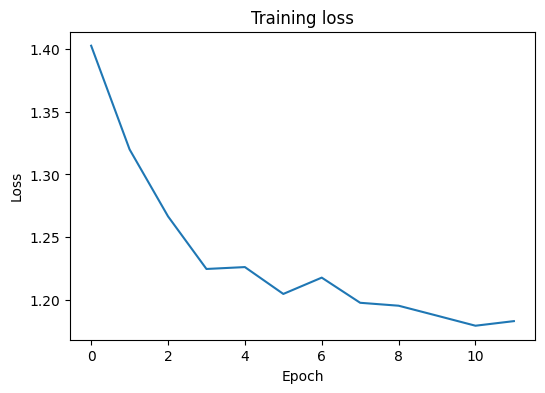

In [11]:
# Plot training loss over epochs
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

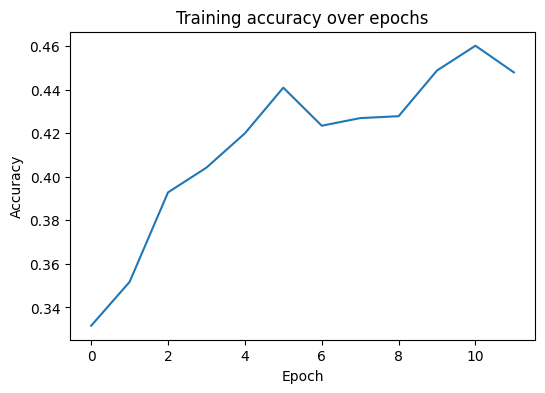

In [12]:
#Training accuracy
plt.figure(figsize=(6, 4))
plt.plot(train_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training accuracy over epochs")
plt.show()

## Uncertainty estimation using dropout

Dropout randomly turns off parts of the network. Running the model multiple times gives different predictions, and their variation is used to measure uncertainty.

In [13]:
# Run the model multiple times with dropout to estimate uncertainty
def mc_dropout_inference(model, images, T=10):
    model.train()  # keep dropout active
    preds = []
    for _ in range(T):
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds.append(probs)

    preds = torch.stack(preds) 
    mean_pred = preds.mean(dim=0)                  
    variance = preds.var(dim=0).mean(dim=1)          

    # Entropy of mean prediction
    entropy = -(mean_pred * torch.log(mean_pred + 1e-8)).sum(dim=1) 

    return mean_pred, variance, entropy

## Evaluation on the test set

The uncertainty estimation is applied to the full test set. For each image, we store the predicted label, the true label, the confidence, the variance-based uncertainty, and the entropy-based uncertainty. This allows comparison between correct and incorrect predictions.

In [14]:
# Evaluate uncertainty on the full test set
model.train()  # keep dropout active

all_true = []
all_pred = []
all_conf = []
all_variance = []
all_entropy = []
all_correct = []
all_image_names = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating uncertainty"):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        image_names = batch["image_name"]

        mean_pred, variance, entropy = mc_dropout_inference(model, images, T=10)

        preds = torch.argmax(mean_pred, dim=1)
        conf = mean_pred.max(dim=1).values

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())
        all_conf.extend(conf.cpu().numpy())
        all_variance.extend(variance.cpu().numpy())
        all_entropy.extend(entropy.cpu().numpy())
        all_correct.extend((preds == labels).cpu().numpy())
        all_image_names.extend(image_names)

results_df = pd.DataFrame({
    "image_name": all_image_names,
    "true_label": all_true,
    "pred_label": all_pred,
    "confidence": all_conf,
    "variance": all_variance,
    "entropy": all_entropy,
    "correct": all_correct })

results_df.head()

Evaluating uncertainty: 100%|██████████| 16/16 [00:24<00:00,  1.51s/it]


,image_name,true_label,pred_label,confidence,variance,entropy,correct
0,mmac_task_1_val_0001.png,3,2,0.302439,0.000546,1.562911,False
1,mmac_task_1_val_0002.png,3,2,0.351060,0.000878,1.421252,False
2,mmac_task_1_val_0003.png,2,2,0.343943,0.000758,1.429675,True
3,mmac_task_1_val_0004.png,2,1,0.404147,0.000988,1.270172,False
4,mmac_task_1_val_0005.png,2,1,0.337615,0.000334,1.412192,False


In [15]:
#Summary of prediction correctness
num_correct = results_df["correct"].sum()
num_total = len(results_df)
accuracy = num_correct / num_total

print("Number of correct predictions:", num_correct)
print("Number of test samples:", num_total)
print("Test accuracy:", accuracy)

Number of correct predictions: 99
Number of test samples: 248
Test accuracy: 0.39919354838709675


## Uncertainty and prediction correctness

The uncertainty values are compared between correct and incorrect predictions.

In [16]:
# Separate correct and incorrect predictions
correct_df = results_df[results_df["correct"] == True]
incorrect_df = results_df[results_df["correct"] == False]

# Mean uncertainty (variance)
mean_var_correct = correct_df["variance"].mean()
mean_var_incorrect = incorrect_df["variance"].mean()

# Mean uncertainty (entropy)
mean_ent_correct = correct_df["entropy"].mean()
mean_ent_incorrect = incorrect_df["entropy"].mean()

print("Mean variance (correct):", mean_var_correct)
print("Mean variance (incorrect):", mean_var_incorrect)

print("Mean entropy (correct):", mean_ent_correct)
print("Mean entropy (incorrect):", mean_ent_incorrect)

Mean variance (correct): 0.0013181027
Mean variance (incorrect): 0.001034905
Mean entropy (correct): 1.1386181
Mean entropy (incorrect): 1.2061297


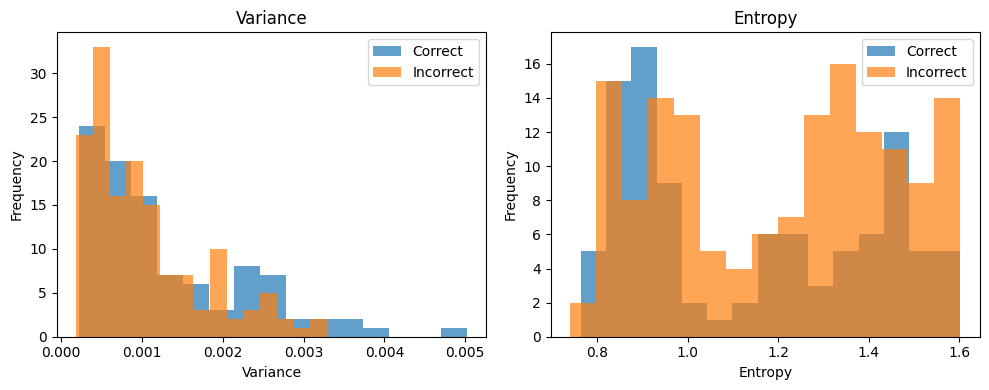

In [17]:
plt.figure(figsize=(10, 4))

# Variance histogram
plt.subplot(1, 2, 1)
correct_var = results_df[results_df["correct"]]["variance"]
incorrect_var = results_df[~results_df["correct"]]["variance"]

plt.hist(correct_var, bins=15, alpha=0.7, label="Correct")
plt.hist(incorrect_var, bins=15, alpha=0.7, label="Incorrect")

plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.title("Variance")
plt.legend()

# Entropy histogram
plt.subplot(1, 2, 2)
correct_ent = results_df[results_df["correct"]]["entropy"]
incorrect_ent = results_df[~results_df["correct"]]["entropy"]

plt.hist(correct_ent, bins=15, alpha=0.7, label="Correct")
plt.hist(incorrect_ent, bins=15, alpha=0.7, label="Incorrect")

plt.xlabel("Entropy")
plt.ylabel("Frequency")
plt.title("Entropy")
plt.legend()

plt.tight_layout()
plt.show()

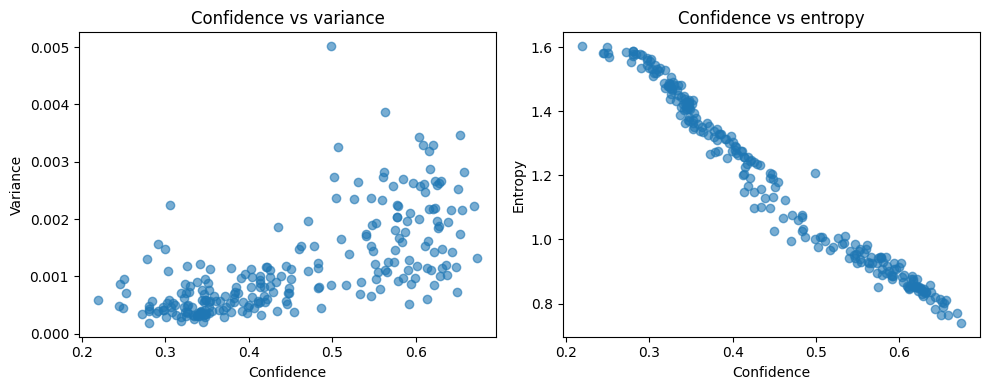

In [18]:
plt.figure(figsize=(10, 4))

# Confidence vs variance
plt.subplot(1, 2, 1)
plt.scatter(results_df["confidence"], results_df["variance"], alpha=0.6)
plt.xlabel("Confidence")
plt.ylabel("Variance")
plt.title("Confidence vs variance")

# Confidence vs entropy
plt.subplot(1, 2, 2)
plt.scatter(results_df["confidence"], results_df["entropy"], alpha=0.6)
plt.xlabel("Confidence")
plt.ylabel("Entropy")
plt.title("Confidence vs entropy")

plt.tight_layout()
plt.show()